# Phase 5 · 02 — Why did the model flag this transaction?

An analyst actions an alert from **reason codes**, not from a score. This notebook explains both models on real 2019 alerts, with values that are *exact* — not sampled approximations — so they can be trusted line by line.

| model | method | unit | cost per alert |
|---|---|---|---|
| XGBoost (@champion) | exact TreeSHAP (`pred_contribs`) folded to source fields | log-odds | microseconds |
| GraphSAGE (@challenger) | exact Shapley over 5 groups of its request subgraph | log-odds | 32 forward passes, ~0.2 s |

GraphSAGE's groups are the questions an analyst asks: was it **the transaction itself**, **how fast the card was spending** (velocity), **the card's history**, **the merchant's history**, or **who the card and merchant are** (identity codes)? Each group is removed along a path the model already knows — empty history, an unseen card, a typical transaction — so "absent" never means an input the model was not trained on (`src/fraud/explain/graph.py`).

Both are in log-odds, so the two models' explanations are on the same scale. Kernel: `fraud` (`.venv`, XGBoost 3.4).

In [1]:
import os, datetime as dt, warnings
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import shap, torch

from fraud.config import load_params, repo_path
from fraud.api.predictor import Predictor, transaction_from_row
from fraud.explain import tree as T, graph as G

warnings.filterwarnings("ignore")
torch.set_num_threads(1)                       # decision 20
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(90); pl.Config.set_tbl_width_chars(160)

params = load_params()
cfg = params["explain"]
SAMPLE = bool(os.getenv("FRAUD_NOTEBOOK_SAMPLE"))
N_ALERTS = 2 if SAMPLE else cfg["n_alerts"] // 2      # per kind: true and false positives
GLOBAL = 2_000 if SAMPLE else cfg["global_sample"]

champion = T.load_champion(params)
# The weights the causal replay scored -- the same ones @challenger v3 serves (decision 23).
gnn = Predictor.from_disk(params, repo_path(params["paths"]["models"]) / "gnn")
print("XGBoost:", len(champion.feature_names), "features | GraphSAGE:", gnn.model_version, "| sample mode:", SAMPLE)

/teamspace/studios/this_studio/financial-fraud-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/teamspace/studios/this_studio/financial-fraud-detection/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


XGBoost: 86 features | GraphSAGE: gnn-local-epoch19 | sample mode: False


## 1 · What XGBoost leans on overall

Mean |SHAP| per **source field** on a 2019 sample — the 86 encoded columns folded back into the 24 fields they came from. Folding is exact because SHAP values are additive.

efficiency: max |sum(SHAP) - margin| = 1.1444091796875e-05


matches the shap library to 0.0


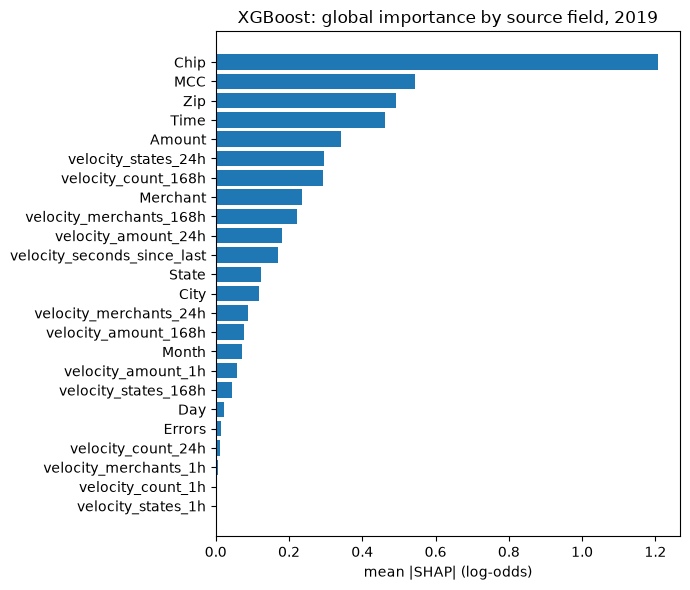

In [2]:
sample = T.matrix_rows(params, years=[2019]).sample(GLOBAL, seed=0)
x = sample.select(champion.feature_names).to_numpy().astype(np.float32)
phi = T.contributions(champion, x)
fields, folded = T.fold(phi, champion.feature_names)

print("efficiency: max |sum(SHAP) - margin| =", float(np.abs(phi.sum(1) - champion.margin(x)).max()))
lib = shap.TreeExplainer(champion.booster).shap_values(x[:500])
print("matches the shap library to", float(np.abs(lib - phi[:500, :-1]).max()))

importance = pl.DataFrame({"field": fields, "mean_abs_shap": np.abs(folded[:, :-1]).mean(0)}).sort("mean_abs_shap")
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance["field"], importance["mean_abs_shap"])
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("XGBoost: global importance by source field, 2019")
plt.tight_layout(); plt.show()

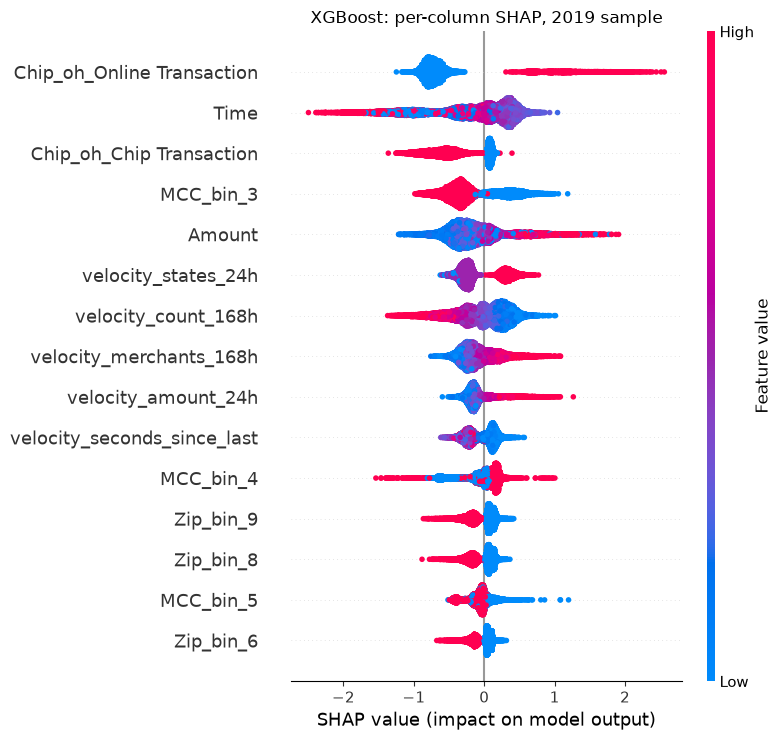

In [3]:
shap.summary_plot(phi[:, :-1], x, feature_names=champion.feature_names, max_display=15, show=False)
plt.title("XGBoost: per-column SHAP, 2019 sample"); plt.tight_layout(); plt.show()

## 2 · Alerts to explain

From each model's 2019 scores, the highest-scored **true positives** and **false positives**. False positives matter as much: they are the alerts that cost an analyst's time and a customer's patience, and the explanation is what lets someone dismiss one quickly.

In [4]:
def pick(path, n):
    z = np.load(repo_path(path))
    frame = pl.DataFrame({"txn_id": z["txn_id"], "score": z["score"], "label": z["label"]}).sort("score", descending=True)
    return pl.concat([frame.filter(pl.col("label") == 1).head(n), frame.filter(pl.col("label") == 0).head(n)])

alerts_x = pick(params["monitoring"]["scores"]["xgboost"]["analysis"], N_ALERTS)
alerts_g = pick(params["monitoring"]["scores"]["graphsage"]["analysis"], N_ALERTS)
ids = sorted(set(alerts_x["txn_id"].to_list()) | set(alerts_g["txn_id"].to_list()))
print(len(ids), "transactions to explain with both models")

36 transactions to explain with both models


## 3 · XGBoost reason codes

In [5]:
rows = T.matrix_rows(params, txn_ids=ids, years=[2019])
xgb_reasons = T.explain_rows(champion, rows, cfg["top_k_reasons"])
(alerts_x.select("txn_id", pl.col("label").alias("fraud"))
 .join(xgb_reasons.drop("fraud"), on="txn_id").sort("score", descending=True)
 .select("txn_id", "fraud", pl.col("score").round(4), "reasons"))

txn_id,fraud,score,reasons
i64,i8,f64,str
2018511,1,0.9854,"""MCC (+1.70) · Zip (+1.51) · Errors (+1.28) · City (+1.04) · velocity_count_168h (+0.91)"""
2458564,0,0.9721,"""Chip (+2.08) · Amount (+1.10) · MCC (+0.95) · velocity_merchants_24h (+0.94) · velocity_me…"
21864257,1,0.9643,"""Zip (+1.58) · velocity_amount_24h (+1.32) · velocity_merchants_24h (+0.95) · MCC (+0.94) ·…"
22896702,1,0.9627,"""Amount (+1.96) · Zip (+1.61) · MCC (+1.19) · City (+1.03) · velocity_amount_24h (+0.77)"""
20807852,0,0.95,"""Chip (+2.83) · MCC (+2.28) · Amount (+1.44) · Zip (+0.58) · Merchant (+0.52)"""
8632465,0,0.9333,"""Chip (+2.96) · MCC (+1.30) · velocity_amount_24h (+0.72) · Zip (+0.71) · velocity_states_2…"
9739745,1,0.9298,"""MCC (+1.48) · Zip (+1.43) · velocity_merchants_24h (+1.24) · City (+1.00) · velocity_state…"
6168543,0,0.9285,"""Chip (+3.04) · MCC (+1.26) · Zip (+0.55) · velocity_states_24h (+0.51) · velocity_amount_2…"
12301137,0,0.9267,"""Chip (+2.82) · MCC (+1.81) · Amount (+1.36) · Merchant (+0.99) · Zip (+0.62)"""


## 4 · GraphSAGE group Shapley

Each transaction's neighbourhood is rebuilt with `seed_rows` — the same past the causal replay showed the model — and then all 32 coalitions of the five groups are scored. The full coalition must reproduce the served score exactly; the values must sum to it.

In [6]:
processed = (pl.scan_parquet(repo_path(params["paths"]["processed"]) / "**/*.parquet", hive_partitioning=True)
             .filter(pl.col("txn_id").is_in(ids)).collect().sort("ts"))
graph_since = dt.datetime(2019, 1, 1) - dt.timedelta(hours=params["serving"]["history_hours"])
typical = G.typical_transaction(params, 2018, sample=50_000 if SAMPLE else 200_000)
print("typical transaction (the 'transaction absent' baseline):", typical)

results, served = {}, {}
for row in processed.iter_rows(named=True):
    txn = transaction_from_row(row)
    nb = G.neighbourhood_for(params, txn, graph_since)
    results[txn["txn_id"]] = G.explain(gnn, txn, nb, typical)
    served[txn["txn_id"]] = gnn.score(txn, nb).score

errors = G.efficiency_errors(results)
match = max(abs(results[t].score - served[t]) for t in results)
print(f"efficiency: max |sum(phi) - (full - baseline)| = {errors.max():.1e}   |   full coalition vs served score: {match:.1e}")

typical transaction (the 'transaction absent' baseline): {'Amount': 29.25, 'City': ' ONLINE', 'State': 'XX', 'Zip': 39305, 'Errors': 'XX', 'Chip': 'Chip Transaction', 'Time': 761, 'Month': 7, 'Day': 16}


efficiency: max |sum(phi) - (full - baseline)| = 3.6e-15   |   full coalition vs served score: 7.8e-08


In [7]:
groups_g = G.as_frame(results)
view = (alerts_g.select("txn_id", pl.col("label").alias("fraud"))
        .join(groups_g, on="txn_id").sort("score", descending=True))
view.select("txn_id", "fraud", pl.col("score").round(4), *[pl.col(g).round(2) for g in G.GROUPS], "top_group")

txn_id,fraud,score,transaction,velocity,card_history,merchant_history,identity,top_group
i64,i8,f64,f64,f64,f64,f64,f64,str
8443998,0,1.0,-2.45,24.84,-2.92,1.1,-0.09,"""velocity"""
12301137,0,1.0,8.07,4.08,0.57,5.4,-0.59,"""transaction"""
6812131,0,1.0,8.64,10.54,-0.97,0.48,-1.25,"""velocity"""
21864260,1,1.0,6.89,8.31,-0.13,1.89,0.35,"""velocity"""
14847773,0,1.0,6.86,6.25,1.28,2.57,-0.15,"""transaction"""
14656442,1,1.0,7.12,6.16,0.34,1.59,1.31,"""transaction"""
18387189,1,1.0,5.24,8.11,1.36,0.73,0.71,"""velocity"""
13334209,0,1.0,7.82,4.45,0.41,2.61,0.75,"""transaction"""
14656444,1,0.9999,6.9,7.72,0.21,1.86,-0.87,"""velocity"""


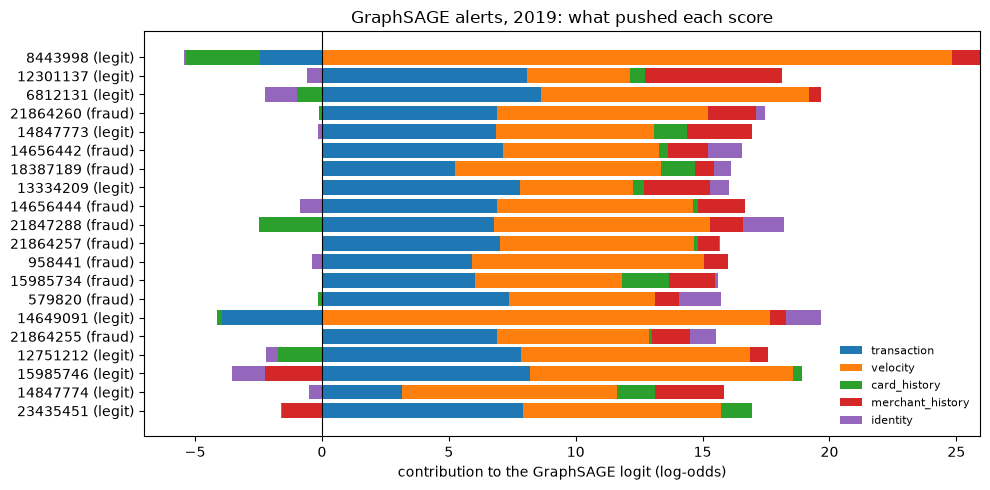

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
labels_ = [f"{t} ({'fraud' if f else 'legit'})" for t, f in zip(view["txn_id"], view["fraud"])]
left_pos = np.zeros(view.height); left_neg = np.zeros(view.height)
for g in G.GROUPS:
    vals = view[g].to_numpy()
    pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
    ax.barh(labels_, pos, left=left_pos, label=g); left_pos += pos
    ax.barh(labels_, neg, left=left_neg, color=ax.patches[-1].get_facecolor()); left_neg += neg
ax.axvline(0, c="k", lw=0.8); ax.invert_yaxis()
ax.set_xlabel("contribution to the GraphSAGE logit (log-odds)")
ax.set_title("GraphSAGE alerts, 2019: what pushed each score"); ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 5 · Same transaction, two models

For every explained alert: what each model would tell the analyst. Where they agree, the reason is robust; where they disagree, the graph is seeing something the tabular model cannot (or the reverse).

In [9]:
both = (pl.DataFrame({"txn_id": ids})
        .join(processed.select("txn_id", pl.col("Fraud").alias("fraud"), "Amount", "Chip", "MCC"), on="txn_id")
        .join(xgb_reasons.select("txn_id", pl.col("score").alias("xgb_score"), pl.col("top_field").alias("xgb_top")), on="txn_id")
        .join(groups_g.select("txn_id", pl.col("score").alias("gnn_score"), pl.col("top_group").alias("gnn_top"),
                              *G.GROUPS), on="txn_id")
        .sort("gnn_score", descending=True))
both.select("txn_id", "fraud", pl.col("xgb_score").round(3), "xgb_top", pl.col("gnn_score").round(3), "gnn_top", "Amount", "Chip")

txn_id,fraud,xgb_score,xgb_top,gnn_score,gnn_top,Amount,Chip
i64,i8,f64,str,f64,str,f64,str
8443998,0,0.004,"""velocity_amount_24h""",1.0,"""velocity""",13.7,"""Chip Transaction"""
12301137,0,0.927,"""Chip""",1.0,"""transaction""",1567.11,"""Online Transaction"""
6812131,0,0.485,"""Chip""",1.0,"""velocity""",1138.61,"""Online Transaction"""
21864260,1,0.672,"""Zip""",1.0,"""velocity""",11.97,"""Swipe Transaction"""
14847773,0,0.661,"""Zip""",1.0,"""transaction""",287.17,"""Swipe Transaction"""
14656442,1,0.898,"""Zip""",1.0,"""transaction""",1.34,"""Swipe Transaction"""
18387189,1,0.871,"""velocity_amount_24h""",1.0,"""velocity""",46.97,"""Chip Transaction"""
13334209,0,0.121,"""Zip""",1.0,"""transaction""",-279.0,"""Swipe Transaction"""
14656444,1,0.865,"""Zip""",1.0,"""velocity""",49.68,"""Swipe Transaction"""


In [10]:
share = (groups_g.select([pl.col(g).clip(lower_bound=0).alias(g) for g in G.GROUPS])
         .sum().transpose(include_header=True, header_name="group", column_names=["positive_log_odds"])
         .with_columns((pl.col("positive_log_odds") / pl.col("positive_log_odds").sum()).round(3).alias("share")))
print("Across the explained GraphSAGE alerts, where the push toward 'fraud' came from:")
share.sort("share", descending=True)

Across the explained GraphSAGE alerts, where the push toward 'fraud' came from:


group,positive_log_odds,share
str,f64,f64
"""velocity""",268.627733,0.471
"""transaction""",234.20379,0.411
"""merchant_history""",39.637465,0.07
"""identity""",17.722383,0.031
"""card_history""",9.815392,0.017


In [11]:
out = repo_path("reports/explain"); out.mkdir(parents=True, exist_ok=True)
if not SAMPLE:
    xgb_reasons.write_parquet(out / "xgboost_reason_codes.parquet")
    groups_g.write_parquet(out / "graphsage_group_shapley.parquet")
    importance.write_csv(out / "xgboost_global_importance.csv")
print("saved" if not SAMPLE else "sample mode: nothing saved")

saved


## Reading the results (full run, 3 Oct 2026)

**Both explanations are exact, and checked.** TreeSHAP sums to XGBoost's margin within 1.1e-05 (float32) and equals the `shap` library's TreeExplainer exactly. GraphSAGE's group values sum to the score difference within 3.6e-15, and the full coalition reproduces the served score within 7.8e-08 — so the explanation is of the input serving actually scored.

**XGBoost's false positives have one cause.** Every top false positive is an *online* transaction, and `Chip = Online Transaction` is its largest push (+2 to +3 log-odds). Its true positives look different: location (`Zip`, `MCC`, `City`) plus 24-hour velocity. The champion has learned "online is risky"; that is the rule behind most of the alerts an analyst would dismiss.

**GraphSAGE's highest alerts are driven by velocity (47% of the positive push) and the transaction itself (41%).** The graph groups contribute little at the very top: merchant history 7%, identity 3%, card history 2%. This is a caveat on the relational story, not a contradiction of it: these are its most confident alerts, saturated near 1.0, while the 2x AUC-PR over XGBoost is earned across the whole ranking. Where the neighbourhood matters is a question for mid-score transactions — the next experiment, not this one.

**The two models disagree in instructive ways.** Transaction 8443998 is legitimate: XGBoost scores it 0.004, GraphSAGE 1.0, entirely on velocity (+24.8 log-odds) — a burst of spending GraphSAGE reads as fraud and XGBoost does not. Disagreements like this are where an explanation earns its keep.

**For production:** `fraud.explain.tree.explain_rows` gives reason codes per alert in microseconds; `fraud.explain.graph.explain` takes ~0.2 s per alert, cheap enough to run on every GraphSAGE alert (not every request) once the neighbourhood comes from `store.fetch_neighbourhood_once`. An `/explain` endpoint is the natural next step.